In [13]:
# CELL 1: Imports & Setup ---

import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path so we can import from src/
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, project_root)

from src.data_loader import load_dataset, separate_features_target, print_class_distribution, get_feature_info
from src.preprocessing import full_preprocessing_pipeline

# Create output directories
os.makedirs(os.path.join(project_root, "figures"), exist_ok=True)
os.makedirs(os.path.join(project_root, "results"), exist_ok=True)
os.makedirs(os.path.join(project_root, "data", "processed"), exist_ok=True)

print("Setup complete!")

Setup complete!


In [14]:
#  Load Dataset ---
df = load_dataset()
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()


Dataset loaded: 123117 samples, 84 columns
Features: 83  |  Target: 'Attack_type'

Shape: (123117, 84)

First 5 rows:


,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [15]:
# Data Types & Missing Values ---
print("Data Types:")
print(df.dtypes.value_counts())
print(f"\nMissing values per column: {df.isnull().sum().sum()} total")
print(f"\nCategorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Data Types:
float64    56
int64      25
object      3
Name: count, dtype: int64

Missing values per column: 0 total

Categorical columns:
['proto', 'service', 'Attack_type']


In [16]:
# Class Distribution Table ---

X, y = separate_features_target(df)
print_class_distribution(y)



 Class Distribution
 Total samples: 123,117
Class                             Count        %  Bar
-----------------------------------------------------------------
DOS_SYN_Hping                    94,659   76.89%  ██████████████████████████████████████
Thing_Speak                       8,108    6.59%  ███
ARP_poisioning                    7,750    6.29%  ███
MQTT_Publish                      4,146    3.37%  █
NMAP_UDP_SCAN                     2,590    2.10%  █
NMAP_XMAS_TREE_SCAN               2,010    1.63%  
NMAP_OS_DETECTION                 2,000    1.62%  
NMAP_TCP_scan                     1,002    0.81%  
DDOS_Slowloris                      534    0.43%  
Wipro_bulb                          253    0.21%  
Metasploit_Brute_Force_SSH           37    0.03%  
NMAP_FIN_SCAN                        28    0.02%  
-----------------------------------------------------------------
Unique classes:                12



In [17]:
# Feature Info ---

numerical, categorical = get_feature_info(X)


Total features: 83
  Numerical:   81
  Categorical: 2 → ['proto', 'service']
  Missing values: 0


Saved to /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/class_distribution.png


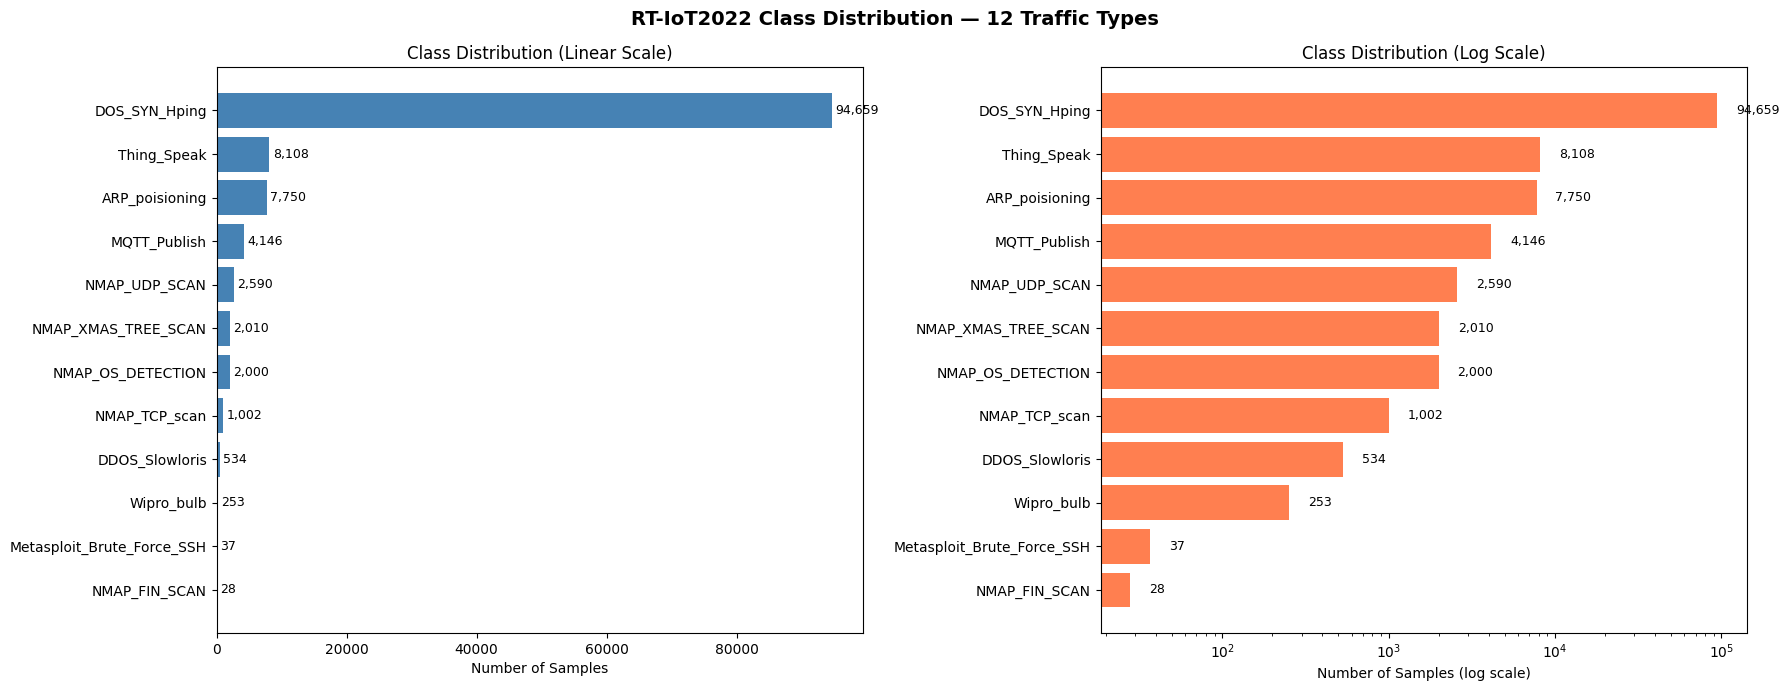

In [18]:
# Class Distribution Bar Chart (LOG SCALE) — Figure 1 for Report ---

counts = y.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Regular scale (shows dominance of DOS_SYN_Hping)
ax1 = axes[0]
bars1 = ax1.barh(counts.index[::-1], counts.values[::-1], color="steelblue")
ax1.set_xlabel("Number of Samples")
ax1.set_title("Class Distribution (Linear Scale)")
for bar, val in zip(bars1, counts.values[::-1]):
    ax1.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=9)

# Plot 2: Log scale (reveals rare classes)
ax2 = axes[1]
bars2 = ax2.barh(counts.index[::-1], counts.values[::-1], color="coral")
ax2.set_xlabel("Number of Samples (log scale)")
ax2.set_title("Class Distribution (Log Scale)")
ax2.set_xscale("log")
for bar, val in zip(bars2, counts.values[::-1]):
    ax2.text(bar.get_width() * 1.3, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=9)

plt.suptitle("RT-IoT2022 Class Distribution — 12 Traffic Types", fontsize=14, fontweight="bold")
plt.tight_layout()

save_path = os.path.join(project_root, "figures", "class_distribution.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved to {save_path}")
plt.show()


In [19]:
# Run Full Preprocessing Pipeline ---

result = full_preprocessing_pipeline(X, y)

X_train = result["X_train"]
X_test = result["X_test"]
y_train = result["y_train"]
y_test = result["y_test"]
target_encoder = result["target_encoder"]

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")


Step 1: Encoding categorical features...
  Encoded 'proto': 3 unique values
  Encoded 'service': 10 unique values

Step 2: Encoding target variable...
  Encoded target: 12 classes
  Mapping: {'ARP_poisioning': 0, 'DDOS_Slowloris': 1, 'DOS_SYN_Hping': 2, 'MQTT_Publish': 3, 'Metasploit_Brute_Force_SSH': 4, 'NMAP_FIN_SCAN': 5, 'NMAP_OS_DETECTION': 6, 'NMAP_TCP_scan': 7, 'NMAP_UDP_SCAN': 8, 'NMAP_XMAS_TREE_SCAN': 9, 'Thing_Speak': 10, 'Wipro_bulb': 11}

Step 3: Stratified train-test split (80/20)...
  Train: 98,493 samples
  Test:  24,624 samples

Step 4: Scaling features...
  Scaled features: mean ≈ 0, std ≈ 1

Preprocessing complete!

X_train: (98493, 83)
X_test:  (24624, 83)


In [20]:
# Verify Stratified Split Proportions ---

train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()

split_comparison = pd.DataFrame({
    "Class": target_encoder.classes_,
    "Train %": (train_dist.values * 100).round(2),
    "Test %": (test_dist.values * 100).round(2),
    "Diff %": ((train_dist.values - test_dist.values).round(4) * 100).round(2)
})

print("Stratified Split Verification:")
print("(Train % and Test % should be nearly identical)")
print(split_comparison.to_string(index=False))

max_diff = split_comparison["Diff %"].abs().max()
print(f"\nMax difference: {max_diff}% — {'Split is stratified' if max_diff < 1 else 'Check split'}")



Stratified Split Verification:
(Train % and Test % should be nearly identical)
                     Class  Train %  Test %  Diff %
            ARP_poisioning     6.29    6.29     0.0
            DDOS_Slowloris     0.43    0.43    -0.0
             DOS_SYN_Hping    76.89   76.88     0.0
              MQTT_Publish     3.37    3.37     0.0
Metasploit_Brute_Force_SSH     0.03    0.03     0.0
             NMAP_FIN_SCAN     0.02    0.02    -0.0
         NMAP_OS_DETECTION     1.62    1.62     0.0
             NMAP_TCP_scan     0.81    0.81     0.0
             NMAP_UDP_SCAN     2.10    2.10     0.0
       NMAP_XMAS_TREE_SCAN     1.63    1.63     0.0
               Thing_Speak     6.59    6.59    -0.0
                Wipro_bulb     0.21    0.21    -0.0

Max difference: 0.0% — Split is stratified


In [21]:
# Rare Class Sample Counts ---

print("\nRare class sample counts after split:")
for cls_name, cls_id in zip(target_encoder.classes_, range(len(target_encoder.classes_))):
    train_count = (y_train == cls_id).sum()
    test_count = (y_test == cls_id).sum()
    if train_count < 500:
        print(f"  {cls_name}: {train_count} train, {test_count} test")



Rare class sample counts after split:
  DDOS_Slowloris: 427 train, 107 test
  Metasploit_Brute_Force_SSH: 30 train, 7 test
  NMAP_FIN_SCAN: 22 train, 6 test
  Wipro_bulb: 202 train, 51 test


In [22]:
# Save Preprocessed Data as .pkl ---

processed_dir = os.path.join(project_root, "data", "processed")

pickle.dump(X_train, open(os.path.join(processed_dir, "X_train_scaled.pkl"), "wb"))
pickle.dump(X_test, open(os.path.join(processed_dir, "X_test_scaled.pkl"), "wb"))
pickle.dump(y_train, open(os.path.join(processed_dir, "y_train.pkl"), "wb"))
pickle.dump(y_test, open(os.path.join(processed_dir, "y_test.pkl"), "wb"))
pickle.dump(target_encoder, open(os.path.join(processed_dir, "target_encoder.pkl"), "wb"))
pickle.dump(result["label_encoders"], open(os.path.join(processed_dir, "label_encoders.pkl"), "wb"))
pickle.dump(result["scaler"], open(os.path.join(processed_dir, "scaler.pkl"), "wb"))

print(f"All files saved to {processed_dir}/")
print("\nFiles saved:")
for f in os.listdir(processed_dir):
    size = os.path.getsize(os.path.join(processed_dir, f)) / (1024 * 1024)
    print(f"  {f} ({size:.1f} MB)")

All files saved to /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/data/processed/

Files saved:
  scaler.pkl (0.0 MB)
  y_train.pkl (0.8 MB)
  X_test_scaled.pkl (15.8 MB)
  y_test.pkl (0.2 MB)
  label_encoders.pkl (0.0 MB)
  target_encoder.pkl (0.0 MB)
  X_train_scaled.pkl (63.1 MB)
